In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zafarali27/car-price-prediction/car_price_prediction_.csv
/kaggle/input/car-prices-dataset/train.csv
/kaggle/input/car-prices-dataset/test.csv


In [32]:
df=pd.read_csv('/kaggle/input/datasets/zafarali27/car-price-prediction/car_price_prediction_.csv')

In [33]:
df.sample(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
559,560,Mercedes,2020,5.4,Petrol,Manual,67965,Used,38126.48,GLA
845,846,Toyota,2012,5.9,Hybrid,Automatic,281298,Like New,81184.90,Camry
2179,2180,Audi,2022,5.3,Diesel,Manual,151460,Used,59627.42,Q5
413,414,Audi,2001,3.9,Electric,Manual,125607,Like New,96779.22,Q7
107,108,Honda,2016,1.9,Diesel,Manual,279773,New,30027.06,Accord


In [34]:
df.sample(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
220,221,Toyota,2016,5.5,Diesel,Manual,61606,Used,59976.03,RAV4
2239,2240,BMW,2023,2.9,Petrol,Manual,243181,New,10708.09,3 Series
1401,1402,Tesla,2011,5.4,Hybrid,Manual,264323,New,6903.27,Model Y
1492,1493,Toyota,2005,4.6,Petrol,Manual,173620,Like New,44014.24,Prius
2367,2368,Mercedes,2023,4.7,Hybrid,Manual,13338,Used,70757.07,GLC


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [36]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [37]:
from scipy import stats

In [38]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(include='object').columns

num_cols = num_cols.drop('Price')

In [39]:
num_cols

Index(['Car ID', 'Year', 'Engine Size', 'Mileage'], dtype='object')

In [40]:
cat_cols

Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object')

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.impute import SimpleImputer

In [76]:
num_preprocessor=Pipeline(steps=[
    ('power transformer',PowerTransformer(method='yeo-johnson')),
    ('Scaling',StandardScaler()),
])

cat_preprocessor=Pipeline(steps=[
    ('ordinal_encoding', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

Here in the categorical columns if the value is ' - ' then it will handle it as -1 

In [77]:
preprocessor=ColumnTransformer(transformers=[
    ('numerical',num_preprocessor,num_cols),
    ('categorical',cat_preprocessor,cat_cols),
    
],remainder='passthrough',verbose_feature_names_out=True)
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('power transformer',
                                                  PowerTransformer()),
                                                 ('Scaling',
                                                  StandardScaler())]),
                                 Index(['Car ID', 'Year', 'Engine Size', 'Mileage'], dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('ordinal_encoding',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object'))])

In [78]:
x=df.drop(['Price'],axis=1)
y=df['Price']

In [79]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [80]:
x_train_p=preprocessor.fit_transform(x_train)
x_test_p=preprocessor.transform(x_test)
# Scale the target variable/
sc=StandardScaler()
y_train_p=sc.fit_transform(pd.DataFrame(y_train))
y_test_p=sc.transform(pd.DataFrame(y_test))


In [81]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state = 42)

rf.fit(x_train_p, y_train)

y_pred = rf.predict(x_test_p)

from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

-0.028788543222372898


# Label encoder is only used for target features and for the trianing features ordinal encoder is used

In [82]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

In [83]:
x_train_p

array([[ 1.06996035e+00, -9.40286615e-01,  1.58328718e-02, ...,
         0.00000000e+00,  1.00000000e+00,  5.00000000e+00],
       [ 9.64553406e-01, -1.08333296e+00, -1.34294452e+00, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [ 8.54190809e-01, -1.36916432e+00,  1.55651836e+00, ...,
         1.00000000e+00,  0.00000000e+00,  1.90000000e+01],
       ...,
       [-4.76697935e-02,  3.51052067e-01, -1.24178322e-01, ...,
         1.00000000e+00,  0.00000000e+00,  2.50000000e+01],
       [ 1.66135074e-01, -8.01786830e-02,  9.41760449e-01, ...,
         1.00000000e+00,  2.00000000e+00,  1.10000000e+01],
       [-4.21296412e-01, -1.22629219e+00,  6.85867720e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [84]:
model=Sequential()

# model.add(Dense(256,activation='relu',input_shape=(x_train_p.shape[1],)))
# model.add(Dropout(0.3))
# BatchNormalization()


model.add(Dense(128,activation='relu',input_shape=(x_train_p.shape[1],),kernel_initializer='glorot_uniform'))

model.add(Dense(64,activation='relu',kernel_initializer='glorot_uniform'))
model.add(Dropout(0.1))
BatchNormalization()

model.add(Dense(32,activation='relu',kernel_initializer='glorot_uniform'))
model.add(Dropout(0.2))
BatchNormalization()

model.add(Dense(1,activation='linear'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
# from keras.utils import plot_model
# plot_model(model)

In [87]:
model.compile(optimizer=Adam(0.01),loss='mean_squared_error',metrics=['r2_score'])

In [88]:
history=model.fit(x_train_p,y_train_p,batch_size=32,epochs=25,validation_split=0.1,verbose=1)

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.0706 - r2_score: -1.1232 - val_loss: 0.9368 - val_r2_score: 9.3818e-05
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0412 - r2_score: -0.0180 - val_loss: 0.9367 - val_r2_score: 1.6773e-04
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9912 - r2_score: -0.0011 - val_loss: 0.9370 - val_r2_score: -8.2135e-05
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0109 - r2_score: -3.4260e-04 - val_loss: 0.9347 - val_r2_score: 0.0024
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0341 - r2_score: 0.0012 - val_loss: 0.9397 - val_r2_score: -0.0030
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9812 - r2_score: -0.0022 - val_loss: 0.9380 - val_r2_score: -0.0012
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9916 - r2_score: -0.0026 - val_loss: 0.9395 - val_r2_score: -0.0027
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0143 - r2_score: -0.0044 - val_l

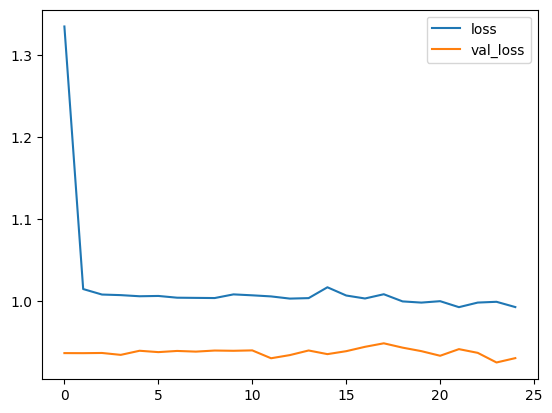

In [89]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()